#Volve Oil Production Prediction

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Volve production data.xlsx to Volve production data.xlsx


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from xgboost import XGBRegressor
from prophet import Prophet

In [4]:
df = pd.read_excel("Volve production data.xlsx")

In [5]:
df.head()

,DATEPRD,WELL_BORE_CODE,NPD_WELL_BORE_CODE,NPD_WELL_BORE_NAME,NPD_FIELD_CODE,NPD_FIELD_NAME,NPD_FACILITY_CODE,NPD_FACILITY_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,...,AVG_CHOKE_UOM,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND,WELL_TYPE
0,2014-04-07,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,0.00000,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,WI
1,2014-04-08,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
2,2014-04-09,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
3,2014-04-10,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
4,2014-04-11,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,310.37614,...,%,33.09788,10.47992,33.07195,0.0,0.0,0.0,NaN,production,OP


In [6]:
df["DATEPRD"] = pd.to_datetime(df["DATEPRD"])
df = df.ffill()
df = df[df['BORE_OIL_VOL'] > 0]


In [7]:
features = [
    'AVG_DOWNHOLE_PRESSURE',
    'AVG_DOWNHOLE_TEMPERATURE',
    'AVG_ANNULUS_PRESS',
    'AVG_WHP_P',
    'AVG_WHT_P',
    'AVG_CHOKE_SIZE_P'
]

In [8]:
x = df[features]
y = df['BORE_OIL_VOL']

In [9]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [10]:
model = XGBRegressor(
    n_estimators = 300,
    learning_rate = 0.05,
    max_depth = 6,
    random_state = 42
)

In [11]:
model.fit(x_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [12]:
y_pred = model.predict(x_test)

In [13]:
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

In [14]:
print(mae, "\n", rmse, "\n", r2)

99.98339500278419 
 216.2783633780335 
 0.9740668072376684


In [15]:

importances = model.feature_importances_

feature_importance= pd.DataFrame({
    "Feature": x.columns,
    "Importance":importances
}).sort_values(by="Importance",ascending=False)


In [16]:
print(feature_importance)

                    Feature  Importance
3                 AVG_WHP_P    0.483094
4                 AVG_WHT_P    0.308636
5          AVG_CHOKE_SIZE_P    0.082617
1  AVG_DOWNHOLE_TEMPERATURE    0.068384
2         AVG_ANNULUS_PRESS    0.035592
0     AVG_DOWNHOLE_PRESSURE    0.021678


<Figure size 300x300 with 0 Axes>

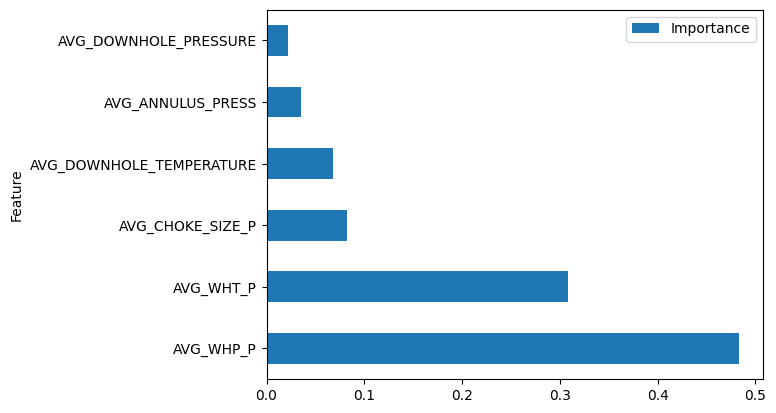

In [17]:
plt.figure(figsize=(3,3))
feature_importance.plot(kind="barh",x="Feature",y="Importance")
plt.show()

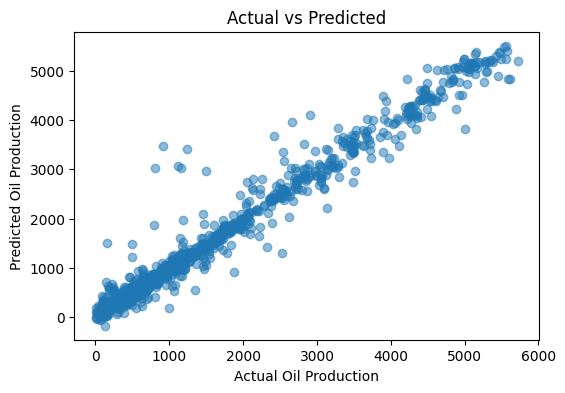

In [18]:
plt.figure(figsize=(6,4))
plt.scatter(y_test,y_pred,alpha=0.5)
plt.xlabel("Actual Oil Production")
plt.ylabel("Predicted Oil Production")
plt.title("Actual vs Predicted")
plt.show()

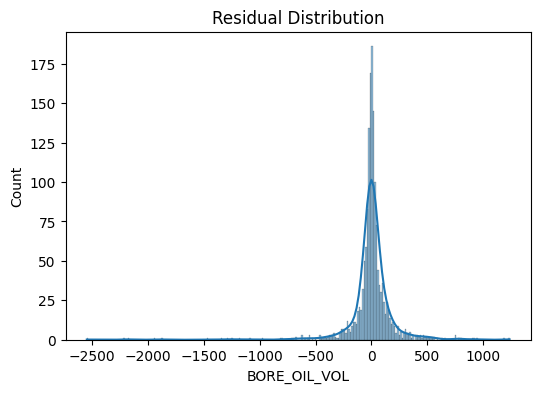

In [19]:
residuals = y_test - y_pred
plt.figure(figsize=(6,4))
sns.histplot(residuals,kde=True)
plt.title("Residual Distribution")
plt.show()

#Time Series Forecasting with Prophet

In [48]:
prophet_df = df[['DATEPRD','BORE_OIL_VOL']]
prophet_df.columns = ['ds','y']

In [49]:
prophet_model = Prophet(
    daily_seasonality=True,
    growth='linear'
)

In [50]:
prophet_model.fit(prophet_df)

In [51]:
future = prophet_model.make_future_dataframe(periods=90)

In [52]:
forecast = prophet_model.predict(future)

<Figure size 800x600 with 0 Axes>

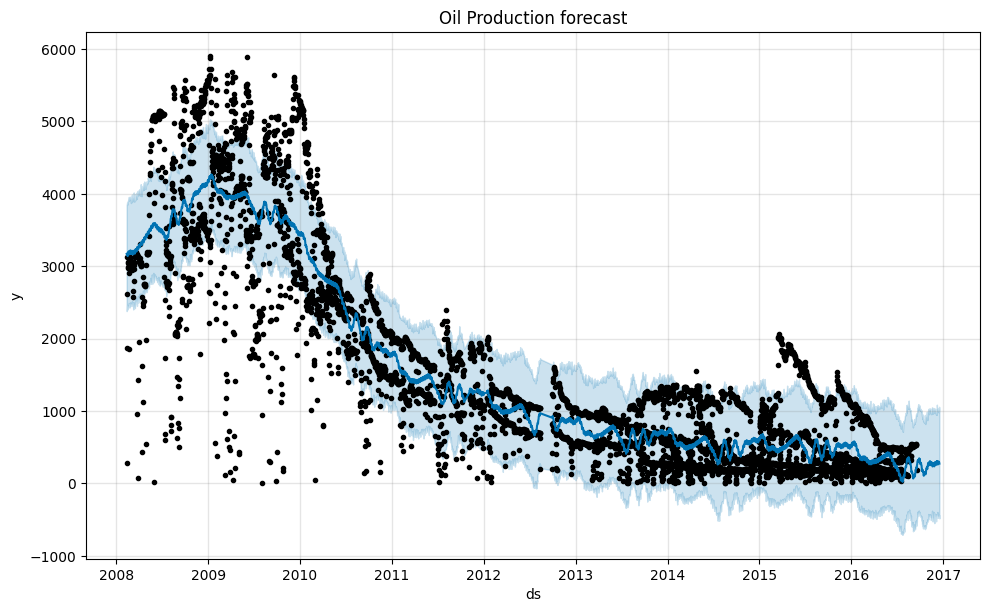

In [53]:
plt.figure(figsize=(8,6))
prophet_model.plot(forecast)
plt.title("Oil Production forecast")
plt.show()

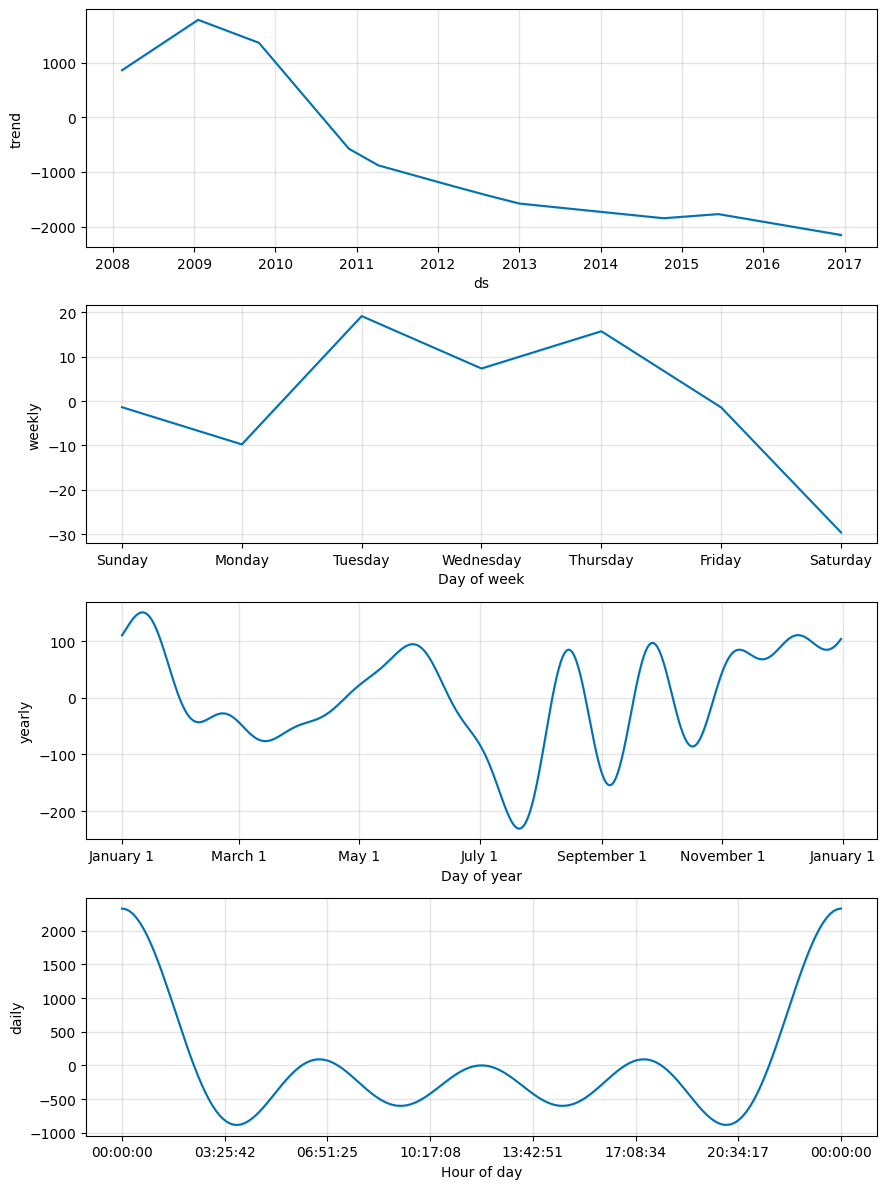

In [54]:
#Trend and seasonality
prophet_model.plot_components(forecast)
plt.show()

## Oil production over time

In [55]:
df_daily = df.groupby(df['DATEPRD'].dt.date)['BORE_OIL_VOL'].sum().reset_index()

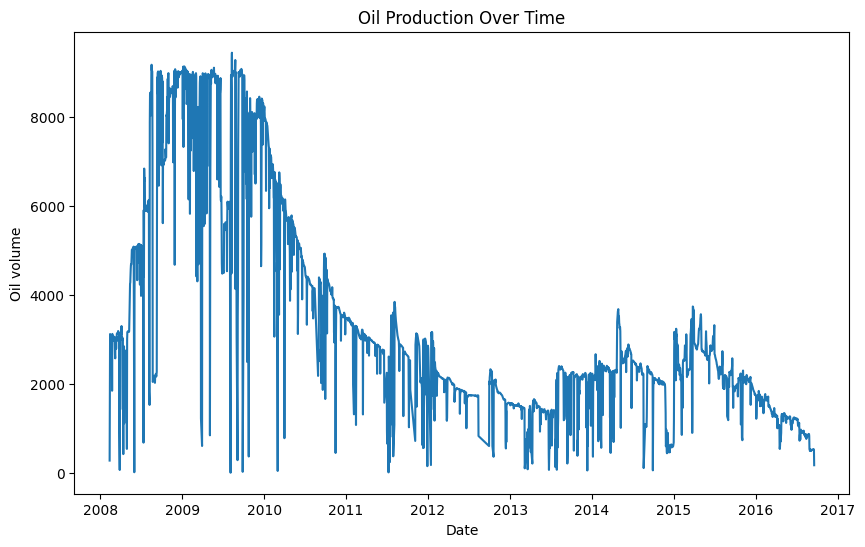

In [56]:
plt.figure(figsize=(10,6))
plt.plot(df_daily['DATEPRD'],df_daily['BORE_OIL_VOL'])
plt.xlabel('Date')
plt.ylabel('Oil volume')
plt.title('Oil Production Over Time')
plt.show()

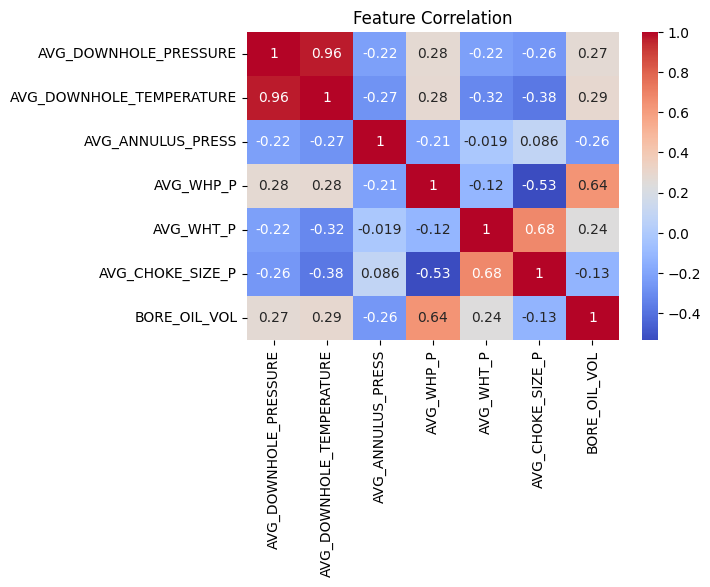

In [45]:
plt.figure(figsize=(6,4))
sns.heatmap(df[features + ['BORE_OIL_VOL']].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()